# Converting Energy Demand and Power Production TSF to Pandas Dataframe
Essentialy, this is just imported code from a github repository provided. It takes the TSF data file and converts it into a Pandas Dataframe for use in Python  

In [1]:
from datetime import datetime
from distutils.util import strtobool

import pandas as pd


# Converts the contents in a .tsf file into a dataframe and returns it along with other meta-data of the dataset: frequency, horizon, whether the dataset contains missing values and whether the series have equal lengths
#
# Parameters
# full_file_path_and_name - complete .tsf file path
# replace_missing_vals_with - a term to indicate the missing values in series in the returning dataframe
# value_column_name - Any name that is preferred to have as the name of the column containing series values in the returning dataframe
def convert_tsf_to_dataframe(
    full_file_path_and_name,
    replace_missing_vals_with="NaN",
    value_column_name="series_value",
):
    col_names = []
    col_types = []
    all_data = {}
    line_count = 0
    frequency = None
    forecast_horizon = None
    contain_missing_values = None
    contain_equal_length = None
    found_data_tag = False
    found_data_section = False
    started_reading_data_section = False

    with open(full_file_path_and_name, "r", encoding="cp1252") as file:
        for line in file:
            # Strip white space from start/end of line
            line = line.strip()

            if line:
                if line.startswith("@"):  # Read meta-data
                    if not line.startswith("@data"):
                        line_content = line.split(" ")
                        if line.startswith("@attribute"):
                            if (
                                len(line_content) != 3
                            ):  # Attributes have both name and type
                                raise Exception("Invalid meta-data specification.")

                            col_names.append(line_content[1])
                            col_types.append(line_content[2])
                        else:
                            if (
                                len(line_content) != 2
                            ):  # Other meta-data have only values
                                raise Exception("Invalid meta-data specification.")

                            if line.startswith("@frequency"):
                                frequency = line_content[1]
                            elif line.startswith("@horizon"):
                                forecast_horizon = int(line_content[1])
                            elif line.startswith("@missing"):
                                contain_missing_values = bool(
                                    strtobool(line_content[1])
                                )
                            elif line.startswith("@equallength"):
                                contain_equal_length = bool(strtobool(line_content[1]))

                    else:
                        if len(col_names) == 0:
                            raise Exception(
                                "Missing attribute section. Attribute section must come before data."
                            )

                        found_data_tag = True
                elif not line.startswith("#"):
                    if len(col_names) == 0:
                        raise Exception(
                            "Missing attribute section. Attribute section must come before data."
                        )
                    elif not found_data_tag:
                        raise Exception("Missing @data tag.")
                    else:
                        if not started_reading_data_section:
                            started_reading_data_section = True
                            found_data_section = True
                            all_series = []

                            for col in col_names:
                                all_data[col] = []

                        full_info = line.split(":")

                        if len(full_info) != (len(col_names) + 1):
                            raise Exception("Missing attributes/values in series.")

                        series = full_info[len(full_info) - 1]
                        series = series.split(",")

                        if len(series) == 0:
                            raise Exception(
                                "A given series should contains a set of comma separated numeric values. At least one numeric value should be there in a series. Missing values should be indicated with ? symbol"
                            )

                        numeric_series = []

                        for val in series:
                            if val == "?":
                                numeric_series.append(replace_missing_vals_with)
                            else:
                                numeric_series.append(float(val))

                        if numeric_series.count(replace_missing_vals_with) == len(
                            numeric_series
                        ):
                            raise Exception(
                                "All series values are missing. A given series should contains a set of comma separated numeric values. At least one numeric value should be there in a series."
                            )

                        all_series.append(pd.Series(numeric_series).array)

                        for i in range(len(col_names)):
                            att_val = None
                            if col_types[i] == "numeric":
                                att_val = int(full_info[i])
                            elif col_types[i] == "string":
                                att_val = str(full_info[i])
                            elif col_types[i] == "date":
                                att_val = datetime.strptime(
                                    full_info[i], "%Y-%m-%d %H-%M-%S"
                                )
                            else:
                                raise Exception(
                                    "Invalid attribute type."
                                )  # Currently, the code supports only numeric, string and date types. Extend this as required.

                            if att_val is None:
                                raise Exception("Invalid attribute value.")
                            else:
                                all_data[col_names[i]].append(att_val)

                line_count = line_count + 1

        if line_count == 0:
            raise Exception("Empty file.")
        if len(col_names) == 0:
            raise Exception("Missing attribute section.")
        if not found_data_section:
            raise Exception("Missing series information under data section.")

        all_data[value_column_name] = all_series
        loaded_data = pd.DataFrame(all_data)

        return (
            loaded_data,
            frequency,
            forecast_horizon,
            contain_missing_values,
            contain_equal_length,
        )


# Example of usage
# loaded_data, frequency, forecast_horizon, contain_missing_values, contain_equal_length = convert_tsf_to_dataframe("TSForecasting/tsf_data/sample.tsf")

# print(loaded_data)
# print(frequency)
# print(forecast_horizon)
# print(contain_missing_values)
# print(contain_equal_length)

In [2]:
testing_dataset = convert_tsf_to_dataframe(r"C:\Users\alpay\Downloads\phase_1_data.tsf",replace_missing_vals_with="NaN",value_column_name="series_value")

# Converting the Solar DataFrame to a Timeseries
To actually analyse the data, the dataframe has to be converted to a timeseries dataframe. Originally, the dataset from converting the dataset only provided each Building and Respective Solar, the time which the data for each buildings data starts, and the actual values of the time series in a list.

Essentially a new dataset was made with index starting from the earliest recorded time from all the buildings and Solar, to the end of September, as according to the project. After, the Buildings and Solar from the original data set were made the columns of the new time_series data set.

To fill in the new dataset, the list of the time series for each building were set to start when the timestamp was, alllocated to the specific timeseries row in the new dataset. With this, the new dataset was now a timeseries with all values for each building and solar in each correct sport respecitvely.

In [3]:
real_set = testing_dataset[0]
real_set


,series_name,start_timestamp,series_value
0,Building0,2016-07-03 21:30:00,"[283.8, 283.8, 283.8, 606.0, 606.0, 606.0, 606..."
1,Building1,2019-01-09 23:15:00,"[8.1, 15.7, 22.8, 32.7, 8.1, 16.5, 24.7, 34.5,..."
2,Building3,2016-03-01 04:15:00,"[1321.0, 1321.0, 1321.0, 1321.0, 1293.0, 1293...."
3,Building4,2019-07-03 04:45:00,"[2.0, NaN, 1.0, 2.0, NaN, 2.0, NaN, NaN, 2.0, ..."
4,Building5,2019-07-25 23:00:00,"[30.0, 31.0, 24.0, 34.0, 30.0, 31.0, 26.0, 33...."
5,Building6,2019-07-25 01:45:00,"[36.8, 34.6, 34.6, 36.2, 36.2, 35.2, 35.2, 35...."
6,Solar0,2020-04-25 14:00:00,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
7,Solar1,2018-12-31 13:00:00,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
8,Solar2,2019-06-05 14:00:00,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
9,Solar3,2019-06-05 14:00:00,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [4]:
index = pd.date_range(start="2016-03-01 04:15:00", end="2020-09-30 23:59:45", freq="15min")
new_headers = real_set["series_name"].dropna().unique().tolist()

series_testing_dataset = pd.DataFrame(columns = new_headers,index = index)

for _, row in real_set.iterrows():

    column = row.series_name
    start_time = pd.to_datetime(row.start_timestamp)
    values = row.series_value

    start_time_index = series_testing_dataset.index.get_loc(start_time)

    series_testing_dataset.iloc[0:start_time_index, series_testing_dataset.columns.get_loc(column)] = 0
    series_testing_dataset.iloc[start_time_index:start_time_index + len(values),series_testing_dataset.columns.get_loc(column)] = values

series_testing_dataset = series_testing_dataset.apply(pd.to_numeric,errors='coerce')
series_testing_dataset

,Building0,Building1,Building3,Building4,Building5,Building6,Solar0,Solar1,Solar2,Solar3,Solar4,Solar5
2016-03-01 04:15:00,0.0,0.0,1321.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00
2016-03-01 04:30:00,0.0,0.0,1321.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00
2016-03-01 04:45:00,0.0,0.0,1321.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00
2016-03-01 05:00:00,0.0,0.0,1321.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00
2016-03-01 05:15:00,0.0,0.0,1293.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
2020-09-30 22:45:00,96.9,14.4,389.0,NaN,NaN,35.6,29.67,6.68,6.34,5.49,4.55,25.28
2020-09-30 23:00:00,96.9,18.8,389.0,1.0,NaN,38.6,29.94,6.71,6.39,5.65,4.57,25.30
2020-09-30 23:15:00,37.4,4.5,415.0,NaN,NaN,38.6,34.02,8.13,7.71,6.83,5.32,28.62
2020-09-30 23:30:00,37.4,9.6,415.0,NaN,NaN,38.6,38.10,9.55,9.03,8.02,6.08,31.94


# Importing Weather Data & Shortening for Usage

In [5]:
Weather_dataset = pd.read_csv(r"C:\Users\alpay\Downloads\ERA5_Weather_Data_Monash.csv")

Weather_dataset.index = Weather_dataset["datetime (UTC)"]
Weather_dataset.set_index("datetime (UTC)", inplace = True)


Weather_dataset.index = pd.to_datetime(Weather_dataset.index)

Start_index = Weather_dataset.index.get_loc("2016-03-01 04:00:00")


New_Weatherset = Weather_dataset.drop(index = Weather_dataset.index[:54028], columns = ["model (name)", "coordinates (lat,lon)", "utc_offset (hrs)"])


New_Weatherset.describe()


,model elevation (surface),temperature (degC),dewpoint_temperature (degC),wind_speed (m/s),mean_sea_level_pressure (Pa),relative_humidity ((0-1)),surface_solar_radiation (W/m^2),surface_thermal_radiation (W/m^2),total_cloud_cover (0-1)
count,4.602900e+04,46029.000000,46029.000000,46029.000000,46029.000000,46029.000000,46029.000000,46029.000000,46029.000000
mean,6.959000e+01,14.752891,9.384980,3.977453,101618.236471,0.725954,179.984864,324.575807,0.599573
std,2.749830e-11,5.551882,3.590544,2.067155,876.393865,0.158980,262.233411,33.044109,0.355192
min,6.959000e+01,0.880000,-2.320000,0.020000,96728.250000,0.130000,0.000000,232.150000,0.000000
25%,6.959000e+01,10.830000,6.750000,2.350000,101151.350000,0.620000,0.000000,300.470000,0.300000
50%,6.959000e+01,13.900000,9.000000,3.760000,101694.910000,0.750000,6.300000,322.910000,0.670000
75%,6.959000e+01,17.910000,11.680000,5.350000,102196.590000,0.850000,311.410000,347.260000,0.950000
max,6.959000e+01,40.360000,22.180000,12.830000,103397.530000,1.000000,1103.920000,458.760000,1.000000


# Solar Data Analysis of Shape and Outliers

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

series_testing_dataset.describe()

,Building0,Building1,Building3,Building4,Building5,Building6,Solar0,Solar1,Solar2,Solar3,Solar4,Solar5
count,113379.000000,160695.000000,160222.000000,143122.000000,130791.000000,158528.000000,160783.000000,160783.000000,160783.000000,160783.000000,160783.000000,160783.000000
mean,205.808722,4.275045,517.935702,0.242115,2.183889,7.631906,0.414900,0.739693,0.541974,0.392017,0.322501,1.450757
std,144.741018,7.339685,273.806102,0.560595,7.746851,13.560105,3.011701,2.321565,1.881633,1.338929,1.136258,5.661619
min,0.000000,0.000000,85.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,157.300000,0.000000,308.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,197.400000,0.000000,392.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,271.000000,7.100000,723.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,6781.500000,83.500000,8556.000000,5.000000,62.000000,102.200000,50.410000,13.040000,13.960000,11.040000,8.100000,40.430000


In [7]:
series_testing_dataset

,Building0,Building1,Building3,Building4,Building5,Building6,Solar0,Solar1,Solar2,Solar3,Solar4,Solar5
2016-03-01 04:15:00,0.0,0.0,1321.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00
2016-03-01 04:30:00,0.0,0.0,1321.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00
2016-03-01 04:45:00,0.0,0.0,1321.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00
2016-03-01 05:00:00,0.0,0.0,1321.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00
2016-03-01 05:15:00,0.0,0.0,1293.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
2020-09-30 22:45:00,96.9,14.4,389.0,NaN,NaN,35.6,29.67,6.68,6.34,5.49,4.55,25.28
2020-09-30 23:00:00,96.9,18.8,389.0,1.0,NaN,38.6,29.94,6.71,6.39,5.65,4.57,25.30
2020-09-30 23:15:00,37.4,4.5,415.0,NaN,NaN,38.6,34.02,8.13,7.71,6.83,5.32,28.62
2020-09-30 23:30:00,37.4,9.6,415.0,NaN,NaN,38.6,38.10,9.55,9.03,8.02,6.08,31.94


In [8]:
series_testing_dataset.isna().sum()
for column in series_testing_dataset.columns:
    start_timestamp = real_set.loc[real_set['series_name'] == column, 'start_timestamp'].iloc[0]
    
    Ratio = (series_testing_dataset[column].isna().sum()/series_testing_dataset[column].iloc[series_testing_dataset.index.get_loc(start_timestamp):].size) *100
    print(column, Ratio)

Building0 31.8553860627646
Building1 0.14549542846750327
Building3 0.34891748505749987
Building4 40.36154215325548
Building5 72.14471278745309
Building6 5.413255875363085
Solar0 0.0
Solar1 0.0
Solar2 0.0
Solar3 0.0
Solar4 0.0
Solar5 0.0


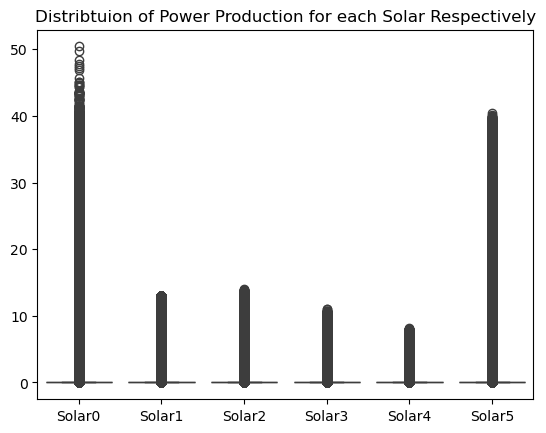

In [17]:
sns.boxplot(data = series_testing_dataset.iloc[:, 6:])
plt.title("Distribtuion of Power Production for each Solar Respectively");

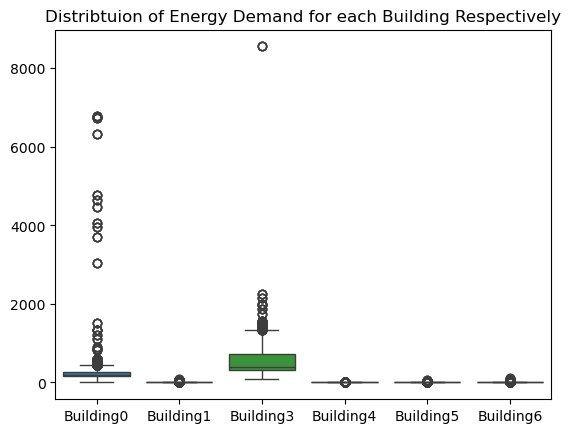

In [18]:
sns.boxplot(data = series_testing_dataset.iloc[:, :6])
plt.title("Distribtuion of Energy Demand for each Building Respectively");

Text(0.5, 1.0, 'Correlation of Buildings')

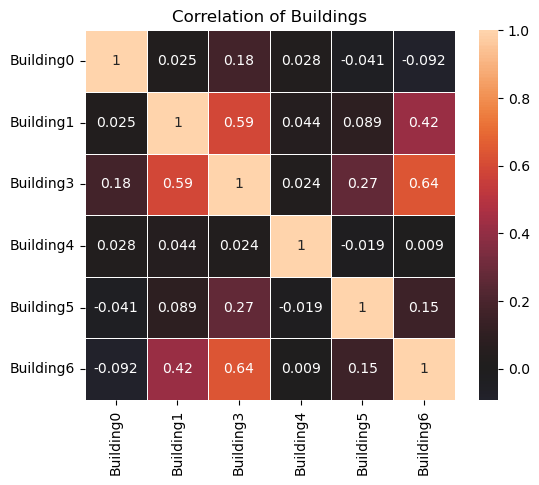

In [123]:
correlation = series_testing_dataset.iloc[:, :6].corr()
sns.heatmap(correlation, annot = True, center = 0, square = True, linewidth = .5);
plt.title("Correlation of Buildings")

Text(0.5, 1.0, 'Building0 Power Usage Series')

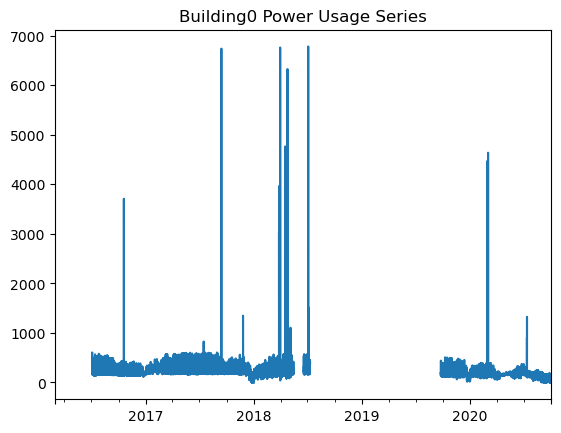

In [24]:
series_testing_dataset["Building0"].plot();
plt.title("Building0 Power Usage Series")

In [32]:
not_nan = True

for idx, item in series_testing_dataset["Building0"].items():
    if not_nan:
        if pd.isna(item):
            print("First NaN at:", idx)
            not_nan = False
    else:
        if not pd.isna(item):
            print("First non-NaN at:", idx)
            not_nan = True

First NaN at: 2016-03-01 04:15:00
First non-NaN at: 2016-07-03 21:30:00
First NaN at: 2016-10-18 15:15:00
First non-NaN at: 2016-10-18 21:30:00
First NaN at: 2017-09-12 16:15:00
First non-NaN at: 2017-09-13 03:45:00
First NaN at: 2017-11-14 15:15:00
First non-NaN at: 2017-11-14 20:00:00
First NaN at: 2017-11-14 20:15:00
First non-NaN at: 2017-11-14 22:15:00
First NaN at: 2017-11-25 02:30:00
First non-NaN at: 2017-11-25 06:15:00
First NaN at: 2017-12-26 01:15:00
First non-NaN at: 2017-12-26 02:15:00
First NaN at: 2017-12-31 01:15:00
First non-NaN at: 2017-12-31 06:15:00
First NaN at: 2018-01-01 02:15:00
First non-NaN at: 2018-01-01 06:15:00
First NaN at: 2018-03-21 04:30:00
First non-NaN at: 2018-03-21 04:45:00
First NaN at: 2018-03-26 05:30:00
First non-NaN at: 2018-03-26 16:15:00
First NaN at: 2018-03-27 16:15:00
First non-NaN at: 2018-03-28 08:30:00
First NaN at: 2018-03-29 06:30:00
First non-NaN at: 2018-03-30 16:45:00
First NaN at: 2018-04-04 06:15:00
First non-NaN at: 2018-04-06 0

Text(0.5, 1.0, 'Building1 Power Usage Series')

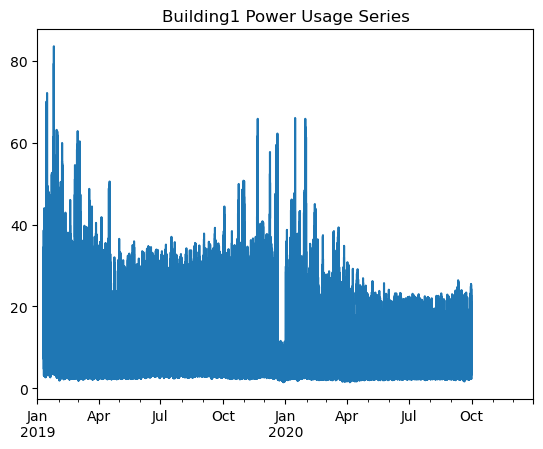

In [44]:
series_testing_dataset["Building1"].plot().set_xlim(pd.Timestamp("2019-01-01"),pd.Timestamp("2020-12-31"));
plt.title("Building1 Power Usage Series")

Text(0.5, 1.0, 'Building3 Power Usage Series')

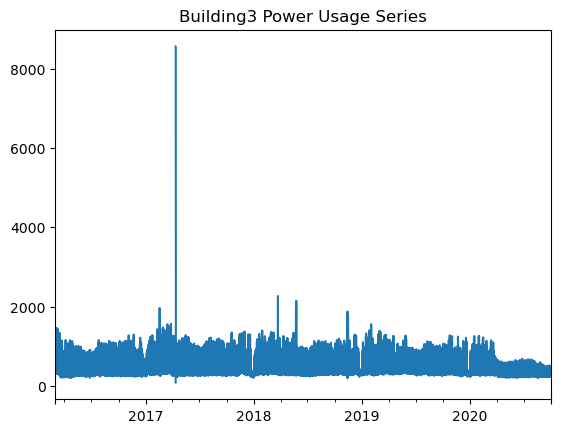

In [38]:
series_testing_dataset["Building3"].plot();
plt.title("Building3 Power Usage Series")

Text(0.5, 1.0, 'Building4 Power Usage Series')

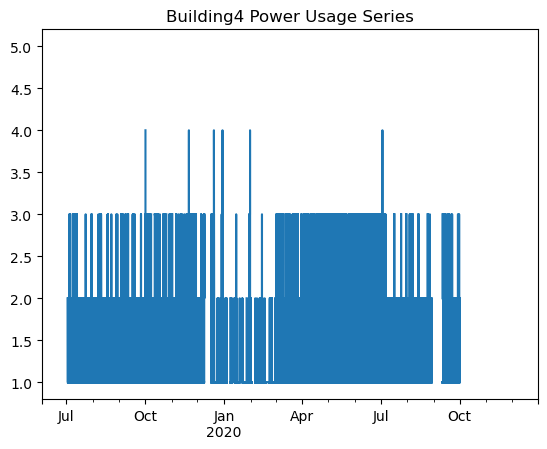

In [50]:
series_testing_dataset["Building4"].plot().set_xlim(pd.Timestamp("2019-06-03"),pd.Timestamp("2020-12-31"));
plt.title("Building4 Power Usage Series")

In [13]:
not_nan = True
first_nan = None

for idx, item in series_testing_dataset["Building4"].items():
    if not_nan:
        if pd.isna(item):
            first_nan = idx
            not_nan = False
    else:
        if not pd.isna(item):
            if idx - first_nan > pd.Timedelta("1 hour"):
                print('Start Nan at:', first_nan )
                print("Final non-NaN at:", idx)
                not_nan = True
                first_nan = None
            not_nan = True

Start Nan at: 2019-07-10 02:15:00
Final non-NaN at: 2019-07-10 03:45:00
Start Nan at: 2019-07-10 04:00:00
Final non-NaN at: 2019-07-10 05:15:00
Start Nan at: 2019-07-10 05:30:00
Final non-NaN at: 2019-07-10 07:15:00
Start Nan at: 2019-07-10 07:30:00
Final non-NaN at: 2019-07-10 09:15:00
Start Nan at: 2019-07-10 09:30:00
Final non-NaN at: 2019-07-10 11:15:00
Start Nan at: 2019-07-10 11:30:00
Final non-NaN at: 2019-07-10 13:00:00
Start Nan at: 2019-07-10 13:15:00
Final non-NaN at: 2019-07-10 14:45:00
Start Nan at: 2019-07-10 15:00:00
Final non-NaN at: 2019-07-10 16:30:00
Start Nan at: 2019-07-10 16:45:00
Final non-NaN at: 2019-07-10 18:00:00
Start Nan at: 2019-07-10 18:15:00
Final non-NaN at: 2019-07-10 19:45:00
Start Nan at: 2019-07-10 20:00:00
Final non-NaN at: 2019-07-10 21:45:00
Start Nan at: 2019-08-24 05:15:00
Final non-NaN at: 2019-08-24 06:30:00
Start Nan at: 2019-08-24 06:45:00
Final non-NaN at: 2019-08-24 08:00:00
Start Nan at: 2019-08-31 05:30:00
Final non-NaN at: 2019-08-31 0

Text(0.5, 1.0, 'Building5 Power Usage Series')

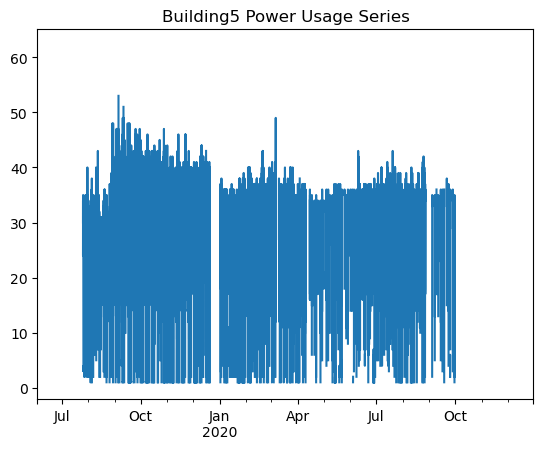

In [52]:
series_testing_dataset["Building5"].plot().set_xlim(pd.Timestamp("2019-06-03"),pd.Timestamp("2020-12-31"));
plt.title("Building5 Power Usage Series")

Text(0.5, 1.0, 'Building6 Power Usage Series')

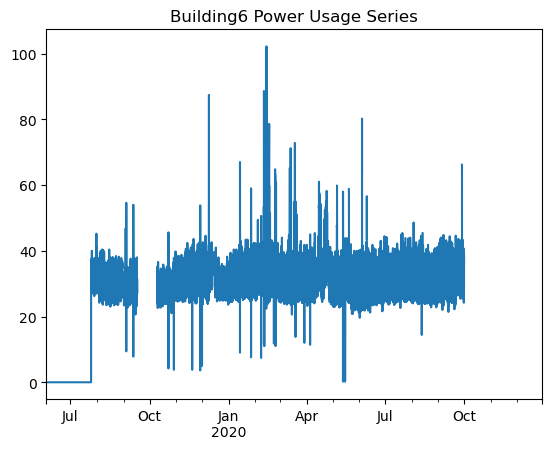

In [ ]:
series_testing_dataset["Building6"].plot().set_xlim(pd.Timestamp("2019-06-03"),pd.Timestamp("2020-12-31"));
plt.title("Building6 Power Usage Series") 	

In [16]:
not_nan = True
first_nan = None

for idx, item in series_testing_dataset["Building6"].items():
    if not_nan:
        if pd.isna(item):
            first_nan = idx
            not_nan = False
    else:
        if not pd.isna(item):
            if idx - first_nan > pd.Timedelta("1 hour"):
                print('Start Nan at:', first_nan )
                print("Final non-NaN at:", idx)
                not_nan = True
                first_nan = None
            not_nan = True

Start Nan at: 2019-09-16 16:00:00
Final non-NaN at: 2019-10-09 19:45:00


# Weather Data Analysis and Outliers

Text(0.5, 1.0, 'Correlation of Weather Features')

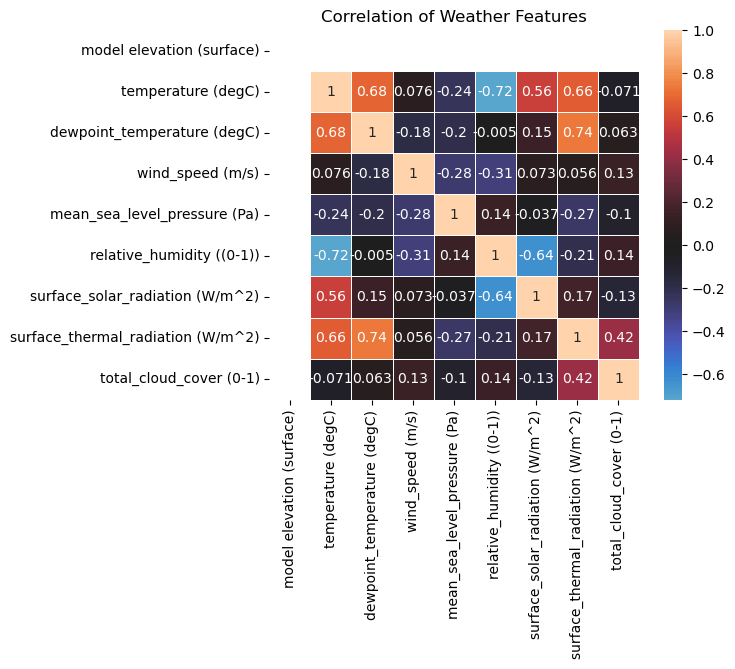

In [222]:
correlation = New_Weatherset.corr()
sns.heatmap(correlation, annot = True, center = 0, square = True, linewidth = .5);
plt.title("Correlation of Weather Features")

# DataFrames for Building Training Sets

### Building0 Dataset

In [6]:
Building0_Dataset = pd.concat([series_testing_dataset.loc["2016-07-03 21:30:00" : "2018-05-14 18:30:00", "Building0"],
                               series_testing_dataset.loc["2019-09-24 00:15:00": "2020-09-30 23:45:00", "Building0"]])
Building0_Dataset

2016-07-03 21:30:00    283.8
2016-07-03 21:45:00    283.8
2016-07-03 22:00:00    283.8
2016-07-03 22:15:00    606.0
2016-07-03 22:30:00    606.0
                       ...  
2020-09-30 22:45:00     96.9
2020-09-30 23:00:00     96.9
2020-09-30 23:15:00     37.4
2020-09-30 23:30:00     37.4
2020-09-30 23:45:00     37.4
Name: Building0, Length: 101076, dtype: float64

### Building1 Dataset

In [7]:
Building1_Dataset = series_testing_dataset.loc["2019-01-09 23:15:00" :"2020-09-30 23:45:00", "Building1"]

Building1_Dataset

2019-01-09 23:15:00     8.1
2019-01-09 23:30:00    15.7
2019-01-09 23:45:00    22.8
2019-01-10 00:00:00    32.7
2019-01-10 00:15:00     8.1
                       ... 
2020-09-30 22:45:00    14.4
2020-09-30 23:00:00    18.8
2020-09-30 23:15:00     4.5
2020-09-30 23:30:00     9.6
2020-09-30 23:45:00    14.0
Freq: 15min, Name: Building1, Length: 60483, dtype: float64

### Building3 Dataset

In [10]:
Building3_Dataset = series_testing_dataset.loc["2017-01-01 00:00:00" : "2020-09-30 23:45:00", "Building3"]

Building3_Dataset

2017-01-01 00:00:00    310.0
2017-01-01 00:15:00    331.0
2017-01-01 00:30:00    331.0
2017-01-01 00:45:00    331.0
2017-01-01 01:00:00    331.0
                       ...  
2020-09-30 22:45:00    389.0
2020-09-30 23:00:00    389.0
2020-09-30 23:15:00    415.0
2020-09-30 23:30:00    415.0
2020-09-30 23:45:00    415.0
Freq: 15min, Name: Building3, Length: 131424, dtype: float64

### Building4 Dataset

In [25]:
Building4_Dataset = series_testing_dataset.loc["2019-07-03 04:45:00" : "2020-09-30 23:45:00", "Building4"]

Building4_Dataset

2019-07-03 04:45:00    2.0
2019-07-03 05:00:00    NaN
2019-07-03 05:15:00    1.0
2019-07-03 05:30:00    2.0
2019-07-03 05:45:00    NaN
                      ... 
2020-09-30 22:45:00    NaN
2020-09-30 23:00:00    1.0
2020-09-30 23:15:00    NaN
2020-09-30 23:30:00    NaN
2020-09-30 23:45:00    NaN
Freq: 15min, Name: Building4, Length: 43757, dtype: float64

### Building6 Dataset

In [26]:
Building6_Dataset = pd.concat([series_testing_dataset.loc["2019-07-25 01:45:00":"2019-09-16 16:00:00", "Building6"],
                               series_testing_dataset.loc["2019-10-09 19:45:00": "2020-09-30 23:45:00", "Building6"]])
Building6_Dataset

2019-07-25 01:45:00    36.8
2019-07-25 02:00:00    34.6
2019-07-25 02:15:00    34.6
2019-07-25 02:30:00    36.2
2019-07-25 02:45:00    36.2
                       ... 
2020-09-30 22:45:00    35.6
2020-09-30 23:00:00    38.6
2020-09-30 23:15:00    38.6
2020-09-30 23:30:00    38.6
2020-09-30 23:45:00    38.6
Name: Building6, Length: 39435, dtype: float64

# Feature Dataset for Building Power Usage
The feature dataset ERA5 Weather report provided to us gives insight into the solar panel power production. However, it doesn't provide any usefulness in prediciting Building Power Usage. Thus, we have compiled various information about Monash University which would be applicable to building power usage.


In [8]:
import pandas as pd 

index = pd.date_range(start="2016-01-01 00:00:00", end="2020-09-30 23:59:45", freq="15min")
Feature_dataset = pd.DataFrame(index = index)


import pandas as pd
import numpy as np

# ============================================================
# 0. PREPARE DATETIME INDEX
# ============================================================

Feature_dataset.index = pd.to_datetime(Feature_dataset.index)
Feature_dataset = Feature_dataset.sort_index()

date = Feature_dataset.index.normalize()
hour = Feature_dataset.index.hour
minute = Feature_dataset.index.minute
time_minutes = hour * 60 + minute


# ============================================================
# 1. HELPER FUNCTION FOR DATE RANGES
# ============================================================

def in_date_ranges(index, ranges):
    dates = index.normalize()
    mask = pd.Series(False, index=index)

    for start, end in ranges:
        start = pd.Timestamp(start)
        end = pd.Timestamp(end)

        mask |= (dates >= start) & (dates <= end)

    return mask.astype(int).values


# ============================================================
# 2. WEEKDAY / WEEKEND
# ============================================================

Feature_dataset["is_weekday"] = (
    Feature_dataset.index.dayofweek < 5
).astype(int)

Feature_dataset["is_weekend"] = (
    Feature_dataset.index.dayofweek >= 5
).astype(int)


# ============================================================
# 3. UNIVERSITY OPEN / CLOSED
# ============================================================

university_open_ranges = [
    ("2016-01-04", "2016-12-22"),
    ("2017-01-03", "2017-12-21"),
    ("2018-01-02", "2018-12-21"),
    ("2019-01-02", "2019-12-23"),
    ("2020-01-02", "2020-12-23"),
]

Feature_dataset["university_open"] = in_date_ranges(
    Feature_dataset.index,
    university_open_ranges
)

Feature_dataset["university_closed"] = (
    1 - Feature_dataset["university_open"]
)


# ============================================================
# 4. CAMPUS FACILITY HOURS
# Mon-Fri: 09:00 - 17:00
# ============================================================

campus_time_open = (
    (time_minutes >= 9 * 60) &
    (time_minutes < 17 * 60)
)

Feature_dataset["campus_facility_hours"] = (
    (Feature_dataset["is_weekday"] == 1) &
    campus_time_open
).astype(int)


# ============================================================
# 5. LIBRARY OPENING HOURS
#
# Weekdays: 08:00 - 22:00
# Weekends: 10:00 - 17:00
# ============================================================

weekday_library = (
    (Feature_dataset["is_weekday"] == 1) &
    (time_minutes >= 8 * 60) &
    (time_minutes < 22 * 60)
)

weekend_library = (
    (Feature_dataset["is_weekend"] == 1) &
    (time_minutes >= 10 * 60) &
    (time_minutes < 17 * 60)
)

Feature_dataset["library_open_hours"] = (
    weekday_library | weekend_library
).astype(int)


# ============================================================
# 6. SEMESTER 1
# ============================================================

semester_1_ranges = [
    ("2016-02-29", "2016-05-27"),
    ("2017-02-21", "2017-05-26"),
    ("2018-02-26", "2018-05-25"),
    ("2019-03-04", "2019-05-31"),
    ("2020-03-09", "2020-06-12"),
]

Feature_dataset["semester_1"] = in_date_ranges(
    Feature_dataset.index,
    semester_1_ranges
)


# ============================================================
# 7. SEMESTER 2
# ============================================================

semester_2_ranges = [
    ("2016-07-25", "2016-10-21"),
    ("2017-07-24", "2017-10-20"),
    ("2018-07-23", "2018-10-19"),
    ("2019-07-29", "2019-10-25"),
    ("2020-08-03", "2020-11-06"),
]

Feature_dataset["semester_2"] = in_date_ranges(
    Feature_dataset.index,
    semester_2_ranges
)

Feature_dataset["semester_active"] = (
    (Feature_dataset["semester_1"] == 1) |
    (Feature_dataset["semester_2"] == 1)
).astype(int)


# ============================================================
# 8. MID-SEMESTER BREAK
# ============================================================

mid_sem_break_ranges = [
    ("2016-03-25", "2016-04-01"),
    ("2016-09-26", "2016-09-30"),

    ("2017-04-14", "2017-04-21"),
    ("2017-09-25", "2017-09-29"),

    ("2018-03-30", "2018-04-06"),
    ("2018-09-24", "2018-09-28"),

    ("2019-04-19", "2019-04-26"),
    ("2019-09-30", "2019-10-04"),

    ("2020-04-10", "2020-04-17"),
    ("2020-09-21", "2020-10-02"),
]

Feature_dataset["mid_sem_break"] = in_date_ranges(
    Feature_dataset.index,
    mid_sem_break_ranges
)


# ============================================================
# 9. ORIENTATION WEEK
# ============================================================

orientation_ranges = [
    ("2016-02-22", "2016-02-26"),
    ("2016-07-18", "2016-07-22"),

    ("2017-02-20", "2017-02-24"),
    ("2017-07-17", "2017-07-21"),

    ("2018-02-19", "2018-02-23"),
    ("2018-07-16", "2018-07-20"),

    ("2019-02-25", "2019-03-01"),
    ("2019-07-22", "2019-07-26"),

    # Semester 1 2020 not listed
    ("2020-07-27", "2020-07-31"),
]

Feature_dataset["orientation_week"] = in_date_ranges(
    Feature_dataset.index,
    orientation_ranges
)


# ============================================================
# 10. SWOT VAC
# ============================================================

swotvac_ranges = [
    ("2016-05-30", "2016-06-03"),
    ("2016-10-24", "2016-10-28"),

    ("2017-05-29", "2017-06-02"),
    ("2017-10-23", "2017-10-27"),

    ("2018-05-28", "2018-06-01"),
    ("2018-10-22", "2018-10-26"),

    ("2019-06-03", "2019-06-07"),
    ("2019-10-28", "2019-11-01"),

    ("2020-06-15", "2020-06-19"),
    ("2020-11-09", "2020-11-13"),
]

Feature_dataset["swotvac"] = in_date_ranges(
    Feature_dataset.index,
    swotvac_ranges
)


# ============================================================
# 11. EXAM PERIOD
# ============================================================

exam_ranges = [
    ("2016-06-06", "2016-06-24"),
    ("2016-10-31", "2016-11-18"),

    ("2017-06-05", "2017-06-23"),
    ("2017-10-30", "2017-11-17"),

    ("2018-06-04", "2018-06-22"),
    ("2018-10-29", "2018-11-16"),

    ("2019-06-10", "2019-06-28"),
    ("2019-11-04", "2019-11-22"),

    ("2020-06-22", "2020-07-10"),
    ("2020-11-16", "2020-12-04"),
]

Feature_dataset["exam_period"] = in_date_ranges(
    Feature_dataset.index,
    exam_ranges
)


# ============================================================
# 12. REMOTE EXAMS - 2020
# ============================================================

Feature_dataset["remote_exam"] = in_date_ranges(
    Feature_dataset.index,
    [("2020-06-22", "2020-07-10")]
)


# ============================================================
# 13. PUBLIC HOLIDAYS
# ============================================================

public_holidays = pd.to_datetime([

    # 2016
    "2016-01-26",
    "2016-03-25",
    "2016-03-28",
    "2016-03-29",
    "2016-04-25",
    "2016-09-30",
    "2016-12-25",
    "2016-12-26",

    # 2017
    "2017-01-26",
    "2017-04-14",
    "2017-04-17",
    "2017-04-18",
    "2017-04-25",
    "2017-09-29",
    "2017-12-25",
    "2017-12-26",

    # 2018
    "2018-01-01",
    "2018-01-26",
    "2018-03-30",
    "2018-04-02",
    "2018-04-03",
    "2018-04-25",
    "2018-09-28",
    "2018-12-25",
    "2018-12-26",

    # 2019
    "2019-01-01",
    "2019-01-28",
    "2019-04-19",
    "2019-04-22",
    "2019-04-23",
    "2019-04-25",
    "2019-09-27",
    "2019-12-25",
    "2019-12-26",

    # 2020
    "2020-01-01",
    "2020-01-27",
    "2020-04-10",
    "2020-04-13",
    "2020-04-14",
    "2020-04-25",
    "2020-10-23",
    "2020-12-25",
    "2020-12-28",
])

Feature_dataset["public_holiday"] = (
    date.isin(public_holidays)
).astype(int)


# ============================================================
# 14. COVID DISRUPTION
# 9 March 2020 onward
# ============================================================

Feature_dataset["covid_disruption"] = (
    date >= pd.Timestamp("2020-03-09")
).astype(int)


# ============================================================
# 15. ONLINE CLASSES
# 9 - 13 March 2020
# ============================================================

Feature_dataset["online_classes"] = in_date_ranges(
    Feature_dataset.index,
    [("2020-03-09", "2020-03-13")]
)


# ============================================================
# 16. COVID CAMPUS RESTRICTIONS
# 16 March - 18 October 2020
# ============================================================

Feature_dataset["covid_restrictions"] = in_date_ranges(
    Feature_dataset.index,
    [("2020-03-16", "2020-10-18")]
)


# ============================================================
# 17. COVID CURFEW PERIOD
# 2 August - 13 September 2020
# ============================================================

Feature_dataset["covid_curfew_period"] = in_date_ranges(
    Feature_dataset.index,
    [("2020-08-02", "2020-09-13")]
)


# ============================================================
# 18. EFFECTIVE CAMPUS OPEN
#
# Combines:
# - University open
# - Weekday
# - 9am-5pm
# - Not public holiday
# - Not COVID restricted
# ============================================================

Feature_dataset["campus_facility_effectively_open"] = (
    (Feature_dataset["university_open"] == 1) &
    (Feature_dataset["is_weekday"] == 1) &
    campus_time_open &
    (Feature_dataset["public_holiday"] == 0) &
    (Feature_dataset["covid_restrictions"] == 0)
).astype(int)


# ============================================================
# 19. EFFECTIVE LIBRARY OPEN
# ============================================================

Feature_dataset["library_effectively_open"] = (
    (Feature_dataset["library_open_hours"] == 1) &
    (Feature_dataset["university_open"] == 1) &
    (Feature_dataset["public_holiday"] == 0) &
    (Feature_dataset["covid_restrictions"] == 0)
).astype(int)


# ============================================================
# 20. TEACHING DAY
# ============================================================

Feature_dataset["teaching_day"] = (
    (Feature_dataset["semester_active"] == 1) &
    (Feature_dataset["is_weekday"] == 1) &
    (Feature_dataset["mid_sem_break"] == 0) &
    (Feature_dataset["public_holiday"] == 0)
).astype(int)


# ============================================================
# 21. CHECK THE CREATED FEATURES
# ============================================================

feature_columns = [
    "is_weekday",
    "is_weekend",
    "university_open",
    "university_closed",
    "campus_facility_hours",
    "library_open_hours",
    "semester_1",
    "semester_2",
    "semester_active",
    "mid_sem_break",
    "orientation_week",
    "swotvac",
    "exam_period",
    "remote_exam",
    "public_holiday",
    "covid_disruption",
    "online_classes",
    "covid_restrictions",
    "covid_curfew_period",
    "campus_facility_effectively_open",
    "library_effectively_open",
    "teaching_day",
]

print(Feature_dataset[feature_columns].head())
print("\nFeature counts:")
print(Feature_dataset[feature_columns].sum())


                     is_weekday  is_weekend  university_open  \
2016-01-01 00:00:00           1           0                0   
2016-01-01 00:15:00           1           0                0   
2016-01-01 00:30:00           1           0                0   
2016-01-01 00:45:00           1           0                0   
2016-01-01 01:00:00           1           0                0   

                     university_closed  campus_facility_hours  \
2016-01-01 00:00:00                  1                      0   
2016-01-01 00:15:00                  1                      0   
2016-01-01 00:30:00                  1                      0   
2016-01-01 00:45:00                  1                      0   
2016-01-01 01:00:00                  1                      0   

                     library_open_hours  semester_1  semester_2  \
2016-01-01 00:00:00                   0           0           0   
2016-01-01 00:15:00                   0           0           0   
2016-01-01 00:30:00    

# Concantonating Feature Dataset for Buildings 0 & 1

### Building 0 Concantonate

In [64]:
features_for_building0 = pd.concat([
    Feature_dataset.loc["2016-07-03 21:30:00":"2018-05-14 18:30:00"],
    Feature_dataset.loc["2019-09-24 00:15:00":"2020-09-30 23:45:00"]
])
Building_0_feature = pd.concat([Building0_Dataset, features_for_building0],axis =1)

Building_0_feature

,Building0,is_weekday,is_weekend,university_open,university_closed,campus_facility_hours,library_open_hours,semester_1,semester_2,semester_active,...,exam_period,remote_exam,public_holiday,covid_disruption,online_classes,covid_restrictions,covid_curfew_period,campus_facility_effectively_open,library_effectively_open,teaching_day
2016-07-03 21:30:00,283.8,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2016-07-03 21:45:00,283.8,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2016-07-03 22:00:00,283.8,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2016-07-03 22:15:00,606.0,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2016-07-03 22:30:00,606.0,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-09-30 22:45:00,96.9,1,0,1,0,0,0,0,1,1,...,0,0,0,1,0,1,0,0,0,0
2020-09-30 23:00:00,96.9,1,0,1,0,0,0,0,1,1,...,0,0,0,1,0,1,0,0,0,0
2020-09-30 23:15:00,37.4,1,0,1,0,0,0,0,1,1,...,0,0,0,1,0,1,0,0,0,0
2020-09-30 23:30:00,37.4,1,0,1,0,0,0,0,1,1,...,0,0,0,1,0,1,0,0,0,0


### Building1 Concantonate

In [65]:
features_for_building1 = Feature_dataset.loc["2019-01-09 23:15:00" :"2020-09-30 23:45:00"]

Building_1_feature = pd.concat([Building1_Dataset, features_for_building1],axis =1)

Building_1_feature

,Building1,is_weekday,is_weekend,university_open,university_closed,campus_facility_hours,library_open_hours,semester_1,semester_2,semester_active,...,exam_period,remote_exam,public_holiday,covid_disruption,online_classes,covid_restrictions,covid_curfew_period,campus_facility_effectively_open,library_effectively_open,teaching_day
2019-01-09 23:15:00,8.1,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2019-01-09 23:30:00,15.7,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2019-01-09 23:45:00,22.8,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2019-01-10 00:00:00,32.7,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2019-01-10 00:15:00,8.1,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-09-30 22:45:00,14.4,1,0,1,0,0,0,0,1,1,...,0,0,0,1,0,1,0,0,0,0
2020-09-30 23:00:00,18.8,1,0,1,0,0,0,0,1,1,...,0,0,0,1,0,1,0,0,0,0
2020-09-30 23:15:00,4.5,1,0,1,0,0,0,0,1,1,...,0,0,0,1,0,1,0,0,0,0
2020-09-30 23:30:00,9.6,1,0,1,0,0,0,0,1,1,...,0,0,0,1,0,1,0,0,0,0


# Testing Data Normalisation

In [41]:
testingNov_dataset = convert_tsf_to_dataframe(r"C:\Users\alpay\Downloads\nov_data.tsf",replace_missing_vals_with="NaN",value_column_name="series_value")
testingNov_dataset = testingNov_dataset[0]
index = pd.date_range(start="2020-10-01 00:00:00", end="2020-11-30 23:45:00", freq = "15min")

new_headers = testingNov_dataset["series_name"].dropna().unique().tolist()

Nov_testing_dataset = pd.DataFrame(columns = new_headers,index = index)

for _, row in testingNov_dataset.iterrows():

    column = row.series_name
    series_start = pd.to_datetime(row.start_timestamp)
    start_time = "2020-10-01 00:00:00"
    wanted_start = pd.to_datetime("2020-10-01 00:00:00")
    wanted_end = pd.to_datetime("2020-11-30 23:45:00")
    values = row.series_value[int((wanted_start - series_start) / pd.Timedelta(minutes=15)):int((wanted_end - series_start) / pd.Timedelta(minutes=15))+1]

    start_time_index = Nov_testing_dataset.index.get_loc(start_time)

    Nov_testing_dataset.iloc[start_time_index:start_time_index + len(values),Nov_testing_dataset.columns.get_loc(column)] = values

Nov_testing_dataset = Nov_testing_dataset.apply(pd.to_numeric,errors='coerce')

Test_Building0 = Nov_testing_dataset["Building0"]
Testing_Building1 = Nov_testing_dataset["Building1"]


In [39]:
# ============================================================
# OCTOBER - NOVEMBER 2020 TEST FEATURE DATASET
# ============================================================

Test_Feature_dataset = pd.DataFrame(
    index=pd.date_range(
        start="2020-10-01 00:00:00",
        end="2020-11-30 23:45:00",
        freq="15min"
    )
)

Test_Feature_dataset.index = pd.to_datetime(Test_Feature_dataset.index)
Test_Feature_dataset = Test_Feature_dataset.sort_index()

date = Test_Feature_dataset.index.normalize()
hour = Test_Feature_dataset.index.hour
minute = Test_Feature_dataset.index.minute
time_minutes = hour * 60 + minute


# ============================================================
# WEEKDAY / WEEKEND
# ============================================================

Test_Feature_dataset["is_weekday"] = (
    Test_Feature_dataset.index.dayofweek < 5
).astype(int)

Test_Feature_dataset["is_weekend"] = (
    Test_Feature_dataset.index.dayofweek >= 5
).astype(int)


# ============================================================
# UNIVERSITY OPEN / CLOSED
# ============================================================

Test_Feature_dataset["university_open"] = in_date_ranges(
    Test_Feature_dataset.index,
    university_open_ranges
)

Test_Feature_dataset["university_closed"] = (
    1 - Test_Feature_dataset["university_open"]
)


# ============================================================
# CAMPUS FACILITY HOURS
# ============================================================

campus_time_open = (
    (time_minutes >= 9 * 60) &
    (time_minutes < 17 * 60)
)

Test_Feature_dataset["campus_facility_hours"] = (
    (Test_Feature_dataset["is_weekday"] == 1) &
    campus_time_open
).astype(int)


# ============================================================
# LIBRARY OPENING HOURS
# ============================================================

weekday_library = (
    (Test_Feature_dataset["is_weekday"] == 1) &
    (time_minutes >= 8 * 60) &
    (time_minutes < 22 * 60)
)

weekend_library = (
    (Test_Feature_dataset["is_weekend"] == 1) &
    (time_minutes >= 10 * 60) &
    (time_minutes < 17 * 60)
)

Test_Feature_dataset["library_open_hours"] = (
    weekday_library | weekend_library
).astype(int)


# ============================================================
# SEMESTERS
# ============================================================

Test_Feature_dataset["semester_1"] = in_date_ranges(
    Test_Feature_dataset.index,
    semester_1_ranges
)

Test_Feature_dataset["semester_2"] = in_date_ranges(
    Test_Feature_dataset.index,
    semester_2_ranges
)

Test_Feature_dataset["semester_active"] = (
    (Test_Feature_dataset["semester_1"] == 1) |
    (Test_Feature_dataset["semester_2"] == 1)
).astype(int)


# ============================================================
# MID-SEMESTER BREAK
# ============================================================

Test_Feature_dataset["mid_sem_break"] = in_date_ranges(
    Test_Feature_dataset.index,
    mid_sem_break_ranges
)


# ============================================================
# ORIENTATION WEEK
# ============================================================

Test_Feature_dataset["orientation_week"] = in_date_ranges(
    Test_Feature_dataset.index,
    orientation_ranges
)


# ============================================================
# SWOTVAC
# ============================================================

Test_Feature_dataset["swotvac"] = in_date_ranges(
    Test_Feature_dataset.index,
    swotvac_ranges
)


# ============================================================
# EXAM PERIOD
# ============================================================

Test_Feature_dataset["exam_period"] = in_date_ranges(
    Test_Feature_dataset.index,
    exam_ranges
)


# ============================================================
# REMOTE EXAMS
# ============================================================

Test_Feature_dataset["remote_exam"] = in_date_ranges(
    Test_Feature_dataset.index,
    [("2020-06-22", "2020-07-10")]
)


# ============================================================
# PUBLIC HOLIDAY
# ============================================================

Test_Feature_dataset["public_holiday"] = (
    date.isin(public_holidays)
).astype(int)


# ============================================================
# COVID FEATURES
# ============================================================

Test_Feature_dataset["covid_disruption"] = (
    date >= pd.Timestamp("2020-03-09")
).astype(int)

Test_Feature_dataset["online_classes"] = in_date_ranges(
    Test_Feature_dataset.index,
    [("2020-03-09", "2020-03-13")]
)

Test_Feature_dataset["covid_restrictions"] = in_date_ranges(
    Test_Feature_dataset.index,
    [("2020-03-16", "2020-10-18")]
)

Test_Feature_dataset["covid_curfew_period"] = in_date_ranges(
    Test_Feature_dataset.index,
    [("2020-08-02", "2020-09-13")]
)


# ============================================================
# EFFECTIVE CAMPUS OPEN
# ============================================================

Test_Feature_dataset["campus_facility_effectively_open"] = (
    (Test_Feature_dataset["university_open"] == 1) &
    (Test_Feature_dataset["is_weekday"] == 1) &
    campus_time_open &
    (Test_Feature_dataset["public_holiday"] == 0) &
    (Test_Feature_dataset["covid_restrictions"] == 0)
).astype(int)


# ============================================================
# EFFECTIVE LIBRARY OPEN
# ============================================================

Test_Feature_dataset["library_effectively_open"] = (
    (Test_Feature_dataset["library_open_hours"] == 1) &
    (Test_Feature_dataset["university_open"] == 1) &
    (Test_Feature_dataset["public_holiday"] == 0) &
    (Test_Feature_dataset["covid_restrictions"] == 0)
).astype(int)


# ============================================================
# TEACHING DAY
# ============================================================

Test_Feature_dataset["teaching_day"] = (
    (Test_Feature_dataset["semester_active"] == 1) &
    (Test_Feature_dataset["is_weekday"] == 1) &
    (Test_Feature_dataset["mid_sem_break"] == 0) &
    (Test_Feature_dataset["public_holiday"] == 0)
).astype(int)


# Keep EXACTLY the same features/order as training
Test_Feature_dataset = Test_Feature_dataset[feature_columns]

Test_Feature_dataset

,is_weekday,is_weekend,university_open,university_closed,campus_facility_hours,library_open_hours,semester_1,semester_2,semester_active,mid_sem_break,...,exam_period,remote_exam,public_holiday,covid_disruption,online_classes,covid_restrictions,covid_curfew_period,campus_facility_effectively_open,library_effectively_open,teaching_day
2020-10-01 00:00:00,1,0,1,0,0,0,0,1,1,1,...,0,0,0,1,0,1,0,0,0,0
2020-10-01 00:15:00,1,0,1,0,0,0,0,1,1,1,...,0,0,0,1,0,1,0,0,0,0
2020-10-01 00:30:00,1,0,1,0,0,0,0,1,1,1,...,0,0,0,1,0,1,0,0,0,0
2020-10-01 00:45:00,1,0,1,0,0,0,0,1,1,1,...,0,0,0,1,0,1,0,0,0,0
2020-10-01 01:00:00,1,0,1,0,0,0,0,1,1,1,...,0,0,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-11-30 22:45:00,1,0,1,0,0,0,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
2020-11-30 23:00:00,1,0,1,0,0,0,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
2020-11-30 23:15:00,1,0,1,0,0,0,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
2020-11-30 23:30:00,1,0,1,0,0,0,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0


In [43]:
Nov_0_testing = pd.concat([Test_Building0, Test_Feature_dataset], axis=1)
Nov_1_testing = pd.concat([Testing_Building1, Test_Feature_dataset], axis=1)

In [44]:
Nov_0_testing['Building0'] = (Nov_0_testing['Building0'] - Nov_0_testing['Building0'].mean()) / Nov_0_testing['Building0'].std()

Nov_1_testing['Building1'] = (Nov_1_testing['Building1'] - Nov_1_testing['Building1'].mean()) / Nov_1_testing['Building1'].std()

Nov_0_testing = pd.concat([
    Nov_0_testing['Building0'].resample("1h").mean(),
    Nov_0_testing.iloc[:, 1:].resample("1h").last()
], axis=1)

Nov_1_testing = pd.concat([
    Nov_1_testing['Building1'].resample("1h").mean(),
    Nov_1_testing.iloc[:, 1:].resample("1h").last()
], axis=1)




In [45]:
Nov_0_testing

,Building0,is_weekday,is_weekend,university_open,university_closed,campus_facility_hours,library_open_hours,semester_1,semester_2,semester_active,...,exam_period,remote_exam,public_holiday,covid_disruption,online_classes,covid_restrictions,covid_curfew_period,campus_facility_effectively_open,library_effectively_open,teaching_day
2020-10-01 00:00:00,-1.485200,1,0,1,0,0,0,0,1,1,...,0,0,0,1,0,1,0,0,0,0
2020-10-01 01:00:00,-1.707082,1,0,1,0,0,0,0,1,1,...,0,0,0,1,0,1,0,0,0,0
2020-10-01 02:00:00,-1.704291,1,0,1,0,0,0,0,1,1,...,0,0,0,1,0,1,0,0,0,0
2020-10-01 03:00:00,-1.605909,1,0,1,0,0,0,0,1,1,...,0,0,0,1,0,1,0,0,0,0
2020-10-01 04:00:00,-1.636261,1,0,1,0,0,0,0,1,1,...,0,0,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-11-30 19:00:00,1.063991,1,0,1,0,0,1,0,0,0,...,1,0,0,1,0,0,0,0,1,0
2020-11-30 20:00:00,1.235286,1,0,1,0,0,1,0,0,0,...,1,0,0,1,0,0,0,0,1,0
2020-11-30 21:00:00,0.942584,1,0,1,0,0,1,0,0,0,...,1,0,0,1,0,0,0,0,1,0
2020-11-30 22:00:00,1.167954,1,0,1,0,0,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0


# Normalisation - Train Data

In [66]:
TRAIN_MEAN0 = Building_0_feature['Building0'].mean()
TRAIN_STD0 = Building_0_feature['Building0'].std()

Building_0_feature['Building0'] = (Building_0_feature['Building0'] - TRAIN_MEAN0) / TRAIN_STD0 if TRAIN_STD0 != 0 else Building_0_feature['Building0']

TRAIN_MEAN1 = Building_1_feature['Building1'].mean()
TRAIN_STD1 = Building_1_feature['Building1'].std()

Building_1_feature['Building1'] = (Building_1_feature['Building1'] - TRAIN_MEAN1) / TRAIN_STD1 if TRAIN_STD1 != 0 else Building_1_feature['Building1']


# Resampling Data - Train Data

In [67]:
Building_0_feature = pd.concat([
    Building_0_feature['Building0'].resample("1h").mean(),
    Building_0_feature.iloc[:, 1:].resample("1h").last()
], axis=1)

Building_1_feature = pd.concat([
    Building_1_feature['Building1'].resample("1h").mean(),
    Building_1_feature.iloc[:, 1:].resample("1h").last()
], axis=1)




# Modelling and Imputation

### Linear Regression

#### BUILDING 0

In [68]:
from sklearn.linear_model import LinearRegression

Linear_Model = LinearRegression(fit_intercept = True)

X_train = Building_0_feature.drop(columns=["Building0"])
y_train = Building_0_feature["Building0"]


X_test = Nov_0_testing.drop(columns=["Building0"])
y_test = Nov_0_testing["Building0"]

X_train_medians = X_train.median()

X_train = X_train.fillna(X_train_medians)
X_test = X_test.fillna(X_train_medians)


y_train = y_train.fillna(y_train.median())

valid = y_test.notna()

X_test = X_test.loc[valid]
y_test = y_test.loc[valid]

Linear_Model.fit(X_train, y_train)

y_pred = Linear_Model.predict(X_test)




In [69]:
optimal_gradient = Linear_Model.coef_[0]
optimal_intercept = Linear_Model.intercept_

print("Intercept:", Linear_Model.intercept_)

for feature, coefficient in zip(X_train.columns, Linear_Model.coef_):
    print(feature, "=", coefficient)

print("RMSE = {:.2f}".format(np.sqrt(np.mean((y_test - y_pred) ** 2))))
print("MAE = {:.2f}".format(np.mean(np.abs(y_test - y_pred))))

Intercept: -0.37168363338851446
is_weekday = 0.030950535630961527
is_weekend = -0.03095053563096135
university_open = 0.3631437507653847
university_closed = -0.3631437507653851
campus_facility_hours = -0.03040746937219553
library_open_hours = 0.212303528937963
semester_1 = 0.5210858477032392
semester_2 = 0.5163439598652984
semester_active = -0.3577974313306087
mid_sem_break = -0.14657120003678314
orientation_week = 0.23310723758595814
swotvac = 0.22773686900178197
exam_period = 0.09866335286957101
remote_exam = 0.4955629578034125
public_holiday = -0.14448644305630268
covid_disruption = -0.5321712028483166
online_classes = 0.0670092475037382
covid_restrictions = -0.2773287873028752
covid_curfew_period = -0.14365453570438314
campus_facility_effectively_open = 0.4314560483766485
library_effectively_open = -0.36560013487779813
teaching_day = 0.11629876362203935
RMSE = 1.00
MAE = 0.76


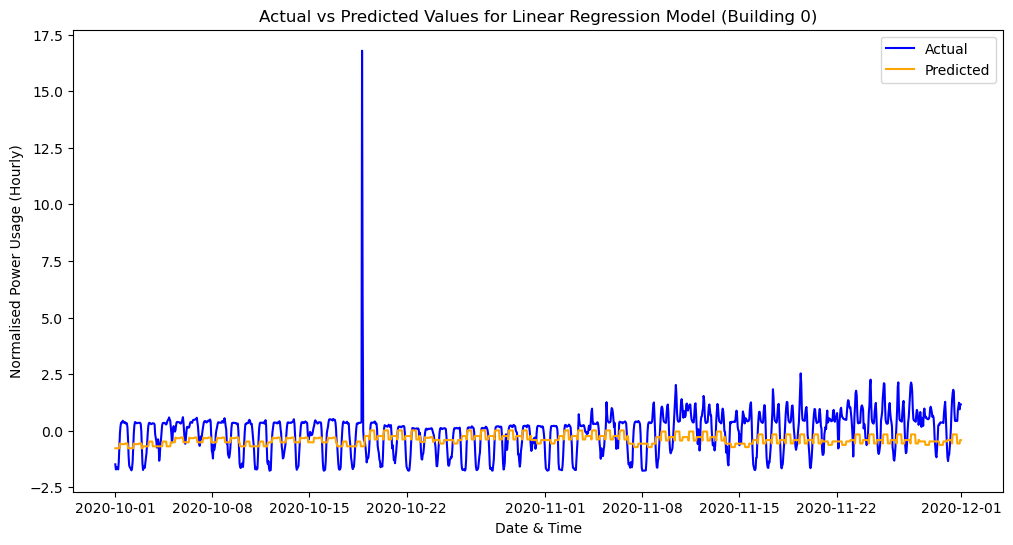

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(y_test.index, y_test, label="Actual", color="blue")
plt.plot(y_test.index, y_pred,label="Predicted", color="orange")
plt.xlabel("Date & Time")
plt.ylabel("Normalised Power Usage (Hourly)")
plt.title("Actual vs Predicted Values for Linear Regression Model (Building 0)")
plt.legend()
plt.show()

In [71]:
y_test_denormed = (y_test * TRAIN_STD0) + TRAIN_MEAN0
y_pred_denormed = (y_pred * TRAIN_STD0) + TRAIN_MEAN0

valid = y_test_denormed != 0

percentage_error = np.abs(
    (y_test_denormed[valid] - y_pred_denormed[valid])
    / y_test_denormed[valid]
) * 100

within_10 = np.mean(percentage_error <= 10) * 100

print("Predictions within ±10% = {:.2f}%".format(within_10))


Predictions within ±10% = 10.15%


#### BUILDING 1

In [74]:
Linear_Model = LinearRegression(fit_intercept = True)

X_train = Building_1_feature.drop(columns=["Building1"])
y_train = Building_1_feature["Building1"]


X_test = Nov_1_testing.drop(columns=["Building1"])
y_test = Nov_1_testing["Building1"]

X_train_medians = X_train.median()

X_train = X_train.fillna(X_train_medians)
X_test = X_test.fillna(X_train_medians)


y_train = y_train.fillna(y_train.median())

valid = y_test.notna()

X_test = X_test.loc[valid]
y_test = y_test.loc[valid]

Linear_Model.fit(X_train, y_train)

y_pred = Linear_Model.predict(X_test)

In [75]:
optimal_gradient = Linear_Model.coef_[0]
optimal_intercept = Linear_Model.intercept_

print("Intercept:", Linear_Model.intercept_)

for feature, coefficient in zip(X_train.columns, Linear_Model.coef_):
    print(feature, "=", coefficient)

print("RMSE = {:.2f}".format(np.sqrt(np.mean((y_test - y_pred) ** 2))))
print("MAE = {:.2f}".format(np.mean(np.abs(y_test - y_pred))))

Intercept: 284127149688.59344
is_weekday = -327623570466.8642
is_weekend = -327623570467.87463
university_open = 43496420779.19997
university_closed = 43496420778.254074
campus_facility_hours = -0.33613026236696364
library_open_hours = -0.3306990575645931
semester_1 = -3261652250248.8
semester_2 = -3261652250248.794
semester_active = 3261652250248.804
mid_sem_break = -0.17043857107580065
orientation_week = 0.03285800512704407
swotvac = -0.05745071796283085
exam_period = -0.10908257994609291
remote_exam = -0.07221242104768402
public_holiday = -0.3661578883485924
covid_disruption = -0.24626717766120443
online_classes = 0.2631644872249635
covid_restrictions = -0.2864952026484496
covid_curfew_period = -0.02515363409551516
campus_facility_effectively_open = -0.0831750497396433
library_effectively_open = -0.34908163100662115
teaching_day = -0.1691491772157476
RMSE = 0.45
MAE = 0.34


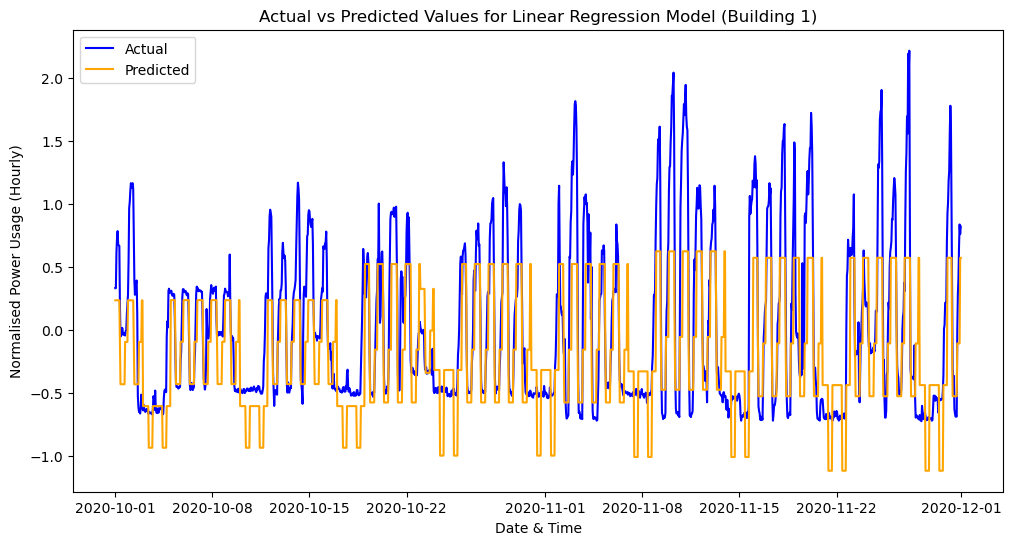

In [76]:
plt.figure(figsize=(12, 6))

plt.plot(y_test.index, y_test, label="Actual", color="blue")
plt.plot(y_test.index, y_pred,label="Predicted", color="orange")
plt.xlabel("Date & Time")
plt.ylabel("Normalised Power Usage (Hourly)")
plt.title("Actual vs Predicted Values for Linear Regression Model (Building 1)")
plt.legend()
plt.show()

In [77]:
y_test_denormed = (y_test * TRAIN_STD1) + TRAIN_MEAN1
y_pred_denormed = (y_pred * TRAIN_STD1) + TRAIN_MEAN1

valid = y_test_denormed != 0

percentage_error = np.abs(
    (y_test_denormed[valid] - y_pred_denormed[valid])
    / y_test_denormed[valid]
) * 100

within_10 = np.mean(percentage_error <= 10) * 100

print("Predictions within ±10% = {:.2f}%".format(within_10))

Predictions within ±10% = 24.39%
